In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [92]:
df = pd.read_csv(r"C:\Coding\Machine_Learning\Machine Learning Coding\Polynomial Regression\Practice Problem\Closed Form\Dataset\Ice_cream selling data.csv")
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [93]:
X = df['Temperature (°C)']
Y = df['Ice Cream Sales (units)']

In [94]:
degree = 2
X_Raw = np.column_stack([X**i for i in range(1,degree + 1)])
X_Raw_Scaled = (X - np.mean(X)) / np.std(X)
X_Scaled = (X_Raw - np.mean(X_Raw, axis = 0))/ np.std(X_Raw, axis = 0)
Y_Scaled = np.array((Y - np.mean(Y))/ np.std(Y)).reshape(-1,1)

In [99]:
X = np.column_stack([np.ones(len(X_Scaled)), X_Scaled])

In [96]:


# Right before your gradient descent loop
print("GD X shape:", X.shape, "first row:", X[0])
print("GD Y shape:", Y_Scaled.shape, "first val:", Y_Scaled[0])

iterations = 10000
ALPHA = 0.05
w = np.zeros(X.shape[1]).reshape(-1,1)
cost_history = []

for i in range (iterations):
    Y_Pred = X @ w

    cost = (1/(2*len(df)) * np.sum((Y_Pred-Y_Scaled)**2))
    cost_history.append(cost)

    gradient = (1/len(df)) * X.T @ (Y_Pred - Y_Scaled)
    w = w - ALPHA * gradient

        
        
print (w)
print(cost)

GD X shape: (49, 3) first row: [ 1.         -1.8479452   2.30711329]
GD Y shape: (49, 1) first val: [2.13674266]
[[ 4.20617115e-16]
 [-1.81392410e-01]
 [ 9.49453903e-01]]
0.0339431454788062


In [97]:
R2 = 1 - (np.sum((Y_Scaled - Y_Pred)**2) / np.sum((Y_Scaled - np.mean(Y_Scaled))**2))
R2

np.float64(0.9321137090423877)

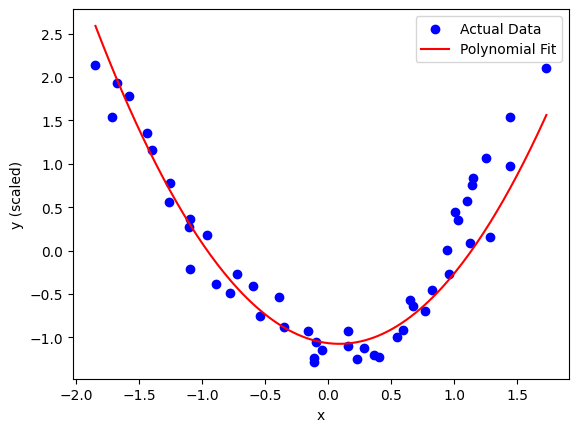

In [100]:
# Sort a smooth range across x's range for a clean curve
x_smooth = np.linspace(X_Raw_Scaled.min(), X_Raw_Scaled.max(), 200)

# Build the SAME polynomial features for this smooth range
X_smooth_raw = np.column_stack([x_smooth**i for i in range(1, degree+1)])

# Scale using the SAME mean/std from training (not new ones!)
X_smooth_scaled = (X_smooth_raw - np.mean(X_smooth_raw, axis=0)) / np.std(X_smooth_raw, axis=0)
X_smooth = np.column_stack([np.ones(len(x_smooth)), X_smooth_scaled])

# Predict
Y_smooth_pred = X_smooth @ w
Y_Pred = X @ w

# Plot
plt.scatter(X_Raw_Scaled, Y_Scaled, color='blue', label='Actual Data')
plt.plot(x_smooth, Y_smooth_pred, color='red', label='Polynomial Fit')
plt.xlabel("x")
plt.ylabel("y (scaled)")
plt.legend()
plt.show()